In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [46]:
# fixed = pd.read_csv("../data/fix_param_test_1.csv")
test_df = pd.read_csv("../data/asymmetry_test_4.csv")

In [47]:
test_df.shape

(50, 22)

In [48]:
test_df.describe()

,Total Kinase,Total Phosphatase,Timestep,Patch Length,dPIP,alphaEnzyme,k_mkon,k_koff,p_mkon,p_koff,...,p_mkcat,p_mKm,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X
count,50.000000,50.000000,50.00,50.0,50.0,5.000000e+01,50.000000,50.000000,50.000000,50.000000,...,50.0,5.000000e+01,50.000000,50.000000,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01
mean,412.571704,545.572612,0.01,0.5,2.0,2.000000e-01,0.010003,0.400235,0.004999,0.020023,...,8.0,4.000000e-01,411.120000,340.740000,2.640877e-02,8.797470e-02,7.827722e-02,6.732596e-02,8.105973e-02,7.865940e-02
std,287.980261,291.974843,0.00,0.0,0.0,5.607473e-17,0.000060,0.002422,0.000027,0.000109,...,0.0,1.121495e-16,286.888846,229.258593,1.218700e-01,2.292137e-01,2.299483e-01,2.078716e-01,2.390691e-01,1.736937e-01
min,27.579839,14.637122,0.01,0.5,2.0,2.000000e-01,0.009903,0.396327,0.004952,0.019806,...,8.0,4.000000e-01,28.000000,1.000000,1.887479e-12,9.613833e-15,3.177759e-14,3.004296e-14,1.680503e-15,3.381601e-10
25%,169.230536,296.800975,0.01,0.5,2.0,2.000000e-01,0.009953,0.398148,0.004977,0.019945,...,8.0,4.000000e-01,169.250000,132.250000,3.928424e-08,2.800984e-11,3.712875e-10,1.152680e-10,1.887938e-09,1.797886e-06
50%,338.155601,594.401675,0.01,0.5,2.0,2.000000e-01,0.010002,0.400434,0.004996,0.020048,...,8.0,4.000000e-01,336.500000,368.000000,1.254740e-06,7.816226e-08,1.953409e-06,8.961396e-09,7.914345e-07,1.473177e-03
75%,724.389890,786.401460,0.01,0.5,2.0,2.000000e-01,0.010058,0.402132,0.005024,0.020118,...,8.0,4.000000e-01,724.500000,526.000000,1.198970e-04,3.667924e-05,4.267119e-04,9.308810e-05,7.321762e-04,9.684113e-02
max,984.236989,997.561674,0.01,0.5,2.0,2.000000e-01,0.010096,0.403987,0.005048,0.020191,...,8.0,4.000000e-01,983.000000,744.000000,6.510664e-01,9.598010e-01,9.706311e-01,8.595044e-01,9.750365e-01,8.909887e-01


In [49]:
result = test_df.iloc[:, 14:]
result.head()

,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X
0,795,64,4.990989e-05,2.268773e-05,0.000037,1.878963e-05,2.489818e-09,0.000020
1,179,133,4.539128e-06,5.449458e-07,0.000703,3.265826e-05,3.720552e-07,0.000184
2,100,132,3.894033e-08,2.735412e-07,0.000176,1.344963e-10,8.299854e-07,0.000044
3,187,37,2.558789e-04,6.987852e-04,0.413452,3.565647e-03,6.291971e-04,0.104586
4,791,1,6.510664e-01,9.598010e-01,0.967153,1.297370e-01,9.235337e-01,0.745056


In [50]:
df = result
for i in range(1, 5):
    result['Polarization Index ' + str(i)] = (df['Average Node ' + str(i) + ' X'] - df['Average Body X'])
result.head()

,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X,Polarization Index 1,Polarization Index 2,Polarization Index 3,Polarization Index 4
0,795,64,4.990989e-05,2.268773e-05,0.000037,1.878963e-05,2.489818e-09,0.000020,-2.722216e-05,-0.000013,-3.112027e-05,-4.990740e-05
1,179,133,4.539128e-06,5.449458e-07,0.000703,3.265826e-05,3.720552e-07,0.000184,-3.994183e-06,0.000699,2.811913e-05,-4.167073e-06
2,100,132,3.894033e-08,2.735412e-07,0.000176,1.344963e-10,8.299854e-07,0.000044,2.346009e-07,0.000176,-3.880583e-08,7.910451e-07
3,187,37,2.558789e-04,6.987852e-04,0.413452,3.565647e-03,6.291971e-04,0.104586,4.429063e-04,0.413196,3.309768e-03,3.733182e-04
4,791,1,6.510664e-01,9.598010e-01,0.967153,1.297370e-01,9.235337e-01,0.745056,3.087346e-01,0.316087,-5.213294e-01,2.724673e-01


In [70]:
df = result
for i in range(1, 5):
    df['Node ' + str(i) + ' is Polarized'] = (df['Polarization Index ' + str(i)] > 0.211) & (df['Average Node ' + str(i) + ' X'] > 0.75)
#         df['Node ' + str(i) + ' is Polarized'] = (df['Polarization Index ' + str(i)] > 0.211)

result.head()

,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X,Polarization Index 1,Polarization Index 2,Polarization Index 3,Polarization Index 4,Node 1 is Polarized,Node 2 is Polarized,Node 3 is Polarized,Node 4 is Polarized,Number of Polarized Nodes
0,795,64,4.990989e-05,2.268773e-05,0.000037,1.878963e-05,2.489818e-09,0.000020,-2.722216e-05,-0.000013,-3.112027e-05,-4.990740e-05,False,False,False,False,0
1,179,133,4.539128e-06,5.449458e-07,0.000703,3.265826e-05,3.720552e-07,0.000184,-3.994183e-06,0.000699,2.811913e-05,-4.167073e-06,False,False,False,False,0
2,100,132,3.894033e-08,2.735412e-07,0.000176,1.344963e-10,8.299854e-07,0.000044,2.346009e-07,0.000176,-3.880583e-08,7.910451e-07,False,False,False,False,0
3,187,37,2.558789e-04,6.987852e-04,0.413452,3.565647e-03,6.291971e-04,0.104586,4.429063e-04,0.413196,3.309768e-03,3.733182e-04,False,False,False,False,0
4,791,1,6.510664e-01,9.598010e-01,0.967153,1.297370e-01,9.235337e-01,0.745056,3.087346e-01,0.316087,-5.213294e-01,2.724673e-01,True,True,False,True,3


In [71]:
node_polarization = result.iloc[:, 12:16].sum().tolist()
node_polarization

[1, 2, 2, 3]

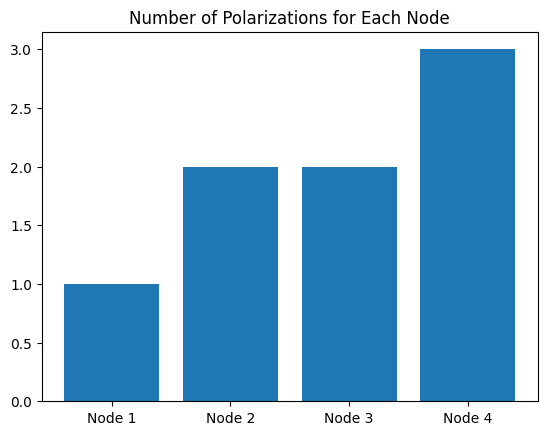

In [72]:
cat = ['Node 1', 'Node 2', 'Node 3', 'Node 4']
plt.bar(cat, node_polarization)
plt.title('Number of Polarizations for Each Node');

In [73]:
node_cols = [f'Node {i} is Polarized' for i in range(1, 5)]
result['Number of Polarized Nodes'] = result[node_cols].sum(axis=1)
result.head()

,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X,Polarization Index 1,Polarization Index 2,Polarization Index 3,Polarization Index 4,Node 1 is Polarized,Node 2 is Polarized,Node 3 is Polarized,Node 4 is Polarized,Number of Polarized Nodes
0,795,64,4.990989e-05,2.268773e-05,0.000037,1.878963e-05,2.489818e-09,0.000020,-2.722216e-05,-0.000013,-3.112027e-05,-4.990740e-05,False,False,False,False,0
1,179,133,4.539128e-06,5.449458e-07,0.000703,3.265826e-05,3.720552e-07,0.000184,-3.994183e-06,0.000699,2.811913e-05,-4.167073e-06,False,False,False,False,0
2,100,132,3.894033e-08,2.735412e-07,0.000176,1.344963e-10,8.299854e-07,0.000044,2.346009e-07,0.000176,-3.880583e-08,7.910451e-07,False,False,False,False,0
3,187,37,2.558789e-04,6.987852e-04,0.413452,3.565647e-03,6.291971e-04,0.104586,4.429063e-04,0.413196,3.309768e-03,3.733182e-04,False,False,False,False,0
4,791,1,6.510664e-01,9.598010e-01,0.967153,1.297370e-01,9.235337e-01,0.745056,3.087346e-01,0.316087,-5.213294e-01,2.724673e-01,True,True,False,True,3


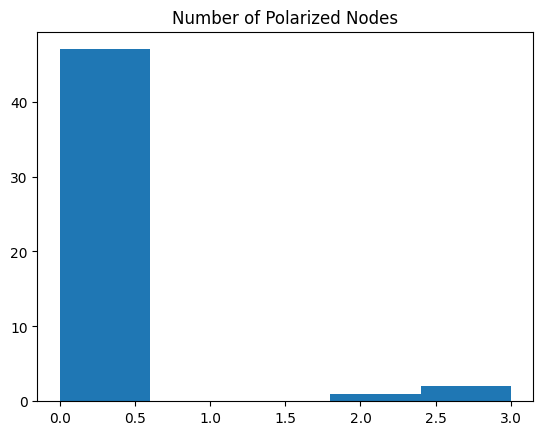

In [74]:
plt.hist(result['Number of Polarized Nodes'], bins=5)
plt.title('Number of Polarized Nodes');